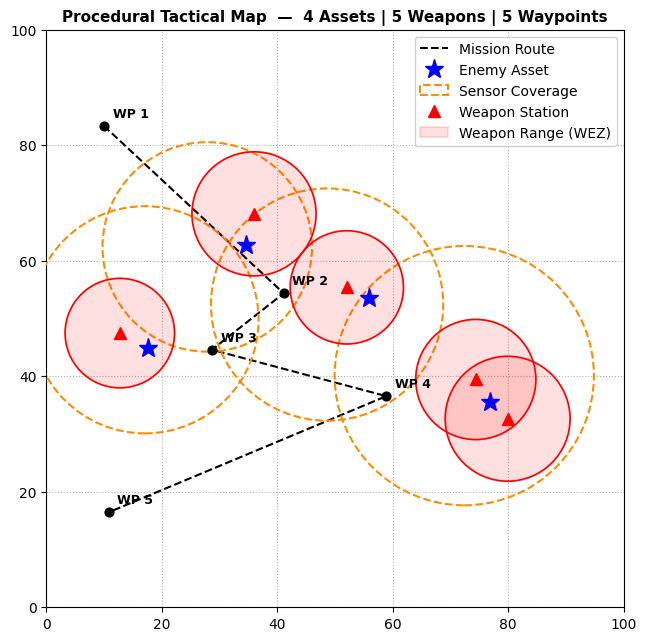

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.linalg as la

np.random.seed()

# ── Kabamba et al. aircraft RCS (normalized, grid-unit²) ─────────────────────
SIGMA_AIRCRAFT = 1.0   # constant RCS; see Kabamba Eq. (4)/(22) for full model

MAX_WEAPONS = 10
num_assets   = np.random.randint(2, 5)    # 2–4 assets

assets  = []
sensors = []
weapons = []

quadrants = [
    (55, 80, 50, 80),
    (15, 45, 15, 45),
    (60, 85, 15, 45),
    (15, 45, 50, 75),
]

weapon_budget = MAX_WEAPONS   # shared budget across all assets

for idx in range(num_assets):
    xmin, xmax, ymin, ymax = quadrants[idx]
    pos_x = np.random.uniform(xmin, xmax)
    pos_y = np.random.uniform(ymin, ymax)
    asset_pos = (pos_x, pos_y)

    assets.append({"pos": asset_pos, "label": f"Asset {idx+1}"})

    # Kabamba et al. radar constants for this sensor (Eq. 5):
    #   Pt = 1 / [1 + (c2 * R^4 / sigma)^c1]
    # c1 controls falloff sharpness; c2 calibrated so Pt = 0.5 at the sensor
    # boundary radius:  c2 * radius^4 / sigma = 1  =>  c2 = sigma / radius^4
    r_sensor = np.random.uniform(18, 26)
    c1_s     = np.random.uniform(0.9, 1.2)     # mild variation between sensors
    c2_s     = SIGMA_AIRCRAFT / r_sensor ** 4  # calibrated to sensor radius

    sensors.append({
        "pos":    (asset_pos[0] + np.random.uniform(-8, 5),
                   asset_pos[1] + np.random.uniform(-8, 5)),
        "radius": r_sensor,
        "c1":     c1_s,
        "c2":     c2_s,
    })

    # Each asset gets 1–3 weapons, capped by remaining budget
    n_w = np.random.randint(1, min(4, weapon_budget + 1))
    weapon_budget -= n_w

    for _ in range(n_w):
        weapons.append({
            "station":    (asset_pos[0] + np.random.uniform(-6, 6),
                           asset_pos[1] + np.random.uniform(-6, 6)),
            "radius":     np.random.uniform(9, 14),   # WEZ circle radius
            "asset_idx":  idx,
        })

    if weapon_budget <= 0:
        break   # hit the global cap

num_waypoints = num_assets + np.random.randint(1, 4)
wp_list = [[10, np.random.uniform(75, 90)]]

for w_idx in range(1, num_waypoints - 1):
    target_sensor = sensors[min(w_idx - 1, len(sensors) - 1)]
    sx, sy = target_sensor["pos"]
    wp_x = np.clip(sx + np.random.uniform(-15, 15), 10, 90)
    wp_y = np.clip(sy + np.random.uniform(-15, 15), 10, 90)
    wp_list.append([wp_x, wp_y])

wp_list.append([np.random.uniform(10, 35), np.random.uniform(10, 30)])
waypoints = np.array(wp_list)

fig, ax1 = plt.subplots(figsize=(8, 7.5))

ax1.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax1.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax1.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for idx, asset in enumerate(assets):
    ax1.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7,
             label='Enemy Asset' if idx == 0 else "")

for idx, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"],
                             edgecolor='darkorange', facecolor='none',
                             linestyle='--', lw=1.5, zorder=4,
                             label='Sensor Coverage' if idx == 0 else "")
    ax1.add_patch(circle)

for idx, weapon in enumerate(weapons):
    xw, yw = weapon["station"]
    r      = weapon["radius"]

    ax1.plot(xw, yw, 'r^', ms=9, zorder=5,
             label='Weapon Station' if idx == 0 else "")

    # Circular WEZ (filled + outline)
    wez_fill = patches.Circle((xw, yw), r,
                               edgecolor='red', facecolor='red',
                               alpha=0.12, lw=1.5, zorder=4,
                               label='Weapon Range (WEZ)' if idx == 0 else "")
    wez_edge = patches.Circle((xw, yw), r,
                               edgecolor='red', facecolor='none',
                               lw=1.2, zorder=4)
    ax1.add_patch(wez_fill)
    ax1.add_patch(wez_edge)

total_weapons = len(weapons)
ax1.set_title(
    f"Procedural Tactical Map  —  {num_assets} Assets | "
    f"{total_weapons} Weapons | {num_waypoints} Waypoints",
    fontsize=11, weight='bold')
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100)
ax1.grid(True, ls=':'); ax1.set_aspect('equal')
ax1.legend(loc='upper right', framealpha=0.9)
plt.show()


**Tracking model — Chap. III Markov chain + Kabamba et al. Eq. (5) & (6)**

Kabamba *et al.* Eq. (5) replaces the binary *in-range / out-of-range* sensor check with a physics-based, continuous instantaneous tracking probability:

$$P_t = \frac{1}{1 + \left(\frac{c_2 R^4}{\sigma}\right)^{c_1}}$$

derived from the radar range equation (SNR ∝ σ / R⁴). This Pt scales the escalation rates in the generator Λ continuously, so the Markov chain naturally captures gradual detection as the aircraft approaches a radar, and gradual loss of track as it recedes.

Kabamba Eq. (6) then computes the *moving average* of Pt over the threat window T = T_resp + T_fo (response + flyout time), which is the upper bound on the probability that a missile is fired and successfully guided:

$$P_d(t) \leq \frac{1}{T}\int_{t-T}^{t} P_t(\tau)\,d\tau$$

For multiple sensors the escalation rates are summed (Chap. III overlap rule: 1/τ_tot = Σ 1/τ_i), each weighted by its own Pt, while regression rates scale with (1 − max Pt).

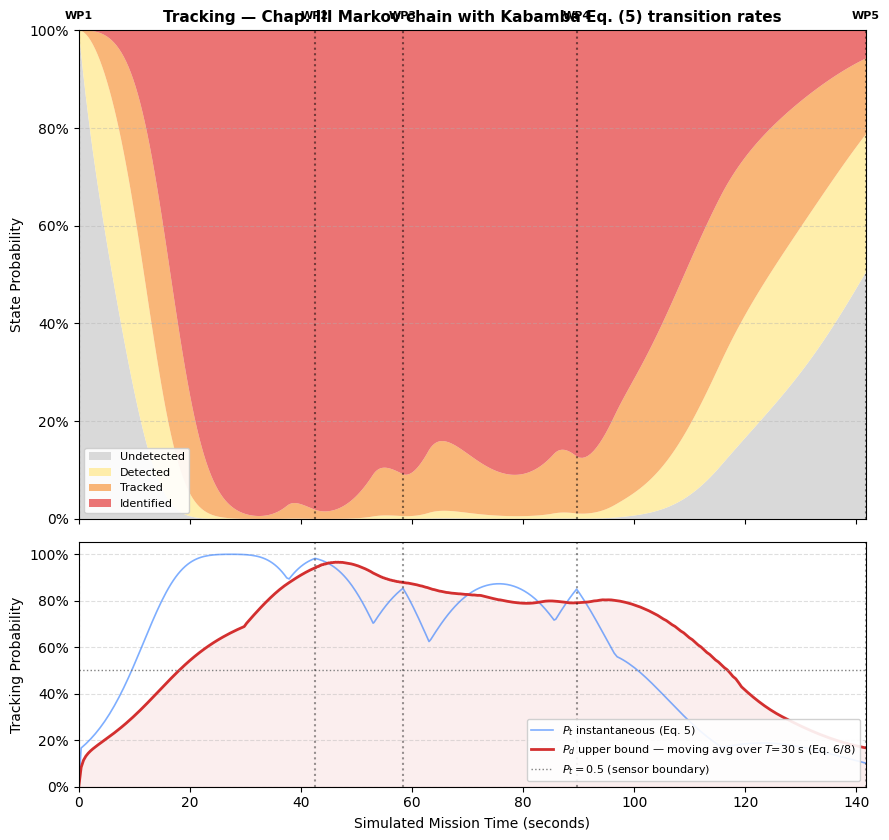

In [2]:
# ── Kabamba et al. Eq. (5): instantaneous tracking probability ───────────────
def kabamba_pt(R, sigma, c1, c2):
    """P_t = 1 / [1 + (c2 * R^4 / sigma)^c1]
    Derived from radar SNR ∝ sigma/R^4 (radar range equation).
    Calibrated per sensor so P_t = 0.5 when R = sensor radius.
    """
    if R < 1e-9:
        return 1.0
    return 1.0 / (1.0 + (c2 * R ** 4 / sigma) ** c1)

# ── Threat-window parameters for Kabamba Eq. (6) / Eq. (8) ──────────────────
T_resp   = 15.0          # radar response time T_resp (time units, Sec. II-C)
T_fo     = 15.0          # missile flyout time  T_fo  (Sec. II-C)
T_threat = T_resp + T_fo # threat window T = T_resp + T_fo

# ── Fine-sample the flight path ──────────────────────────────────────────────
num_steps_per_leg = 100
path_points = []
for i in range(len(waypoints) - 1):
    leg = np.linspace(waypoints[i], waypoints[i+1], num_steps_per_leg, endpoint=False)
    path_points.extend(leg)
path_points.append(waypoints[-1])
path_points = np.array(path_points)

segment_lengths = np.sqrt(np.sum(np.diff(path_points, axis=0) ** 2, axis=1))
time_steps = np.zeros(len(path_points))
time_steps[1:] = np.cumsum(segment_lengths)

# ── Tracking Markov chain initialisation ─────────────────────────────────────
# States: [Undetected, Detected, Tracked, Identified]
prob_history = np.zeros((len(path_points), 4))
prob_history[0] = [1.0, 0.0, 0.0, 0.0]

# Expected transition times (Chap. III, Table I)
tau_UD, tau_DT, tau_TI = 2.5, 3.3, 5.0   # escalation  (right)
tau_DU, tau_TD, tau_IT = 5.0, 5.0, 5.0   # regression  (left)

# Kabamba quantity storage
pt_instant    = np.zeros(len(path_points))  # Eq. (5) instantaneous max P_t
pt_moving_avg = np.zeros(len(path_points))  # Eq. (6) moving average of P_t

# ── Propagate ─────────────────────────────────────────────────────────────────
for t in range(1, len(path_points)):
    dt  = time_steps[t] - time_steps[t - 1]
    pos = path_points[t]

    # -- Kabamba Eq. (5): per-sensor P_t, used to scale transition rates -------
    Lambda  = np.zeros((4, 4))
    max_Pt  = 0.0

    for s in sensors:
        R    = np.linalg.norm(pos - np.array(s["pos"]))
        Pt_s = kabamba_pt(R, SIGMA_AIRCRAFT, s["c1"], s["c2"])
        if Pt_s > max_Pt:
            max_Pt = Pt_s

        # Escalation rates sum over sensors, each weighted by its own P_t
        # (Chap. III overlap rule: 1/tau_tot = Σ_k 1/tau^(k), each now
        #  continuously modulated by the sensor's tracking probability)
        Lambda[0, 1] += Pt_s / tau_UD   # Undetected -> Detected
        Lambda[1, 2] += Pt_s / tau_DT   # Detected   -> Tracked
        Lambda[2, 3] += Pt_s / tau_TI   # Tracked    -> Identified

    # Regression rates scale with (1 − max_P_t): fastest when no sensor tracks
    Lambda[1, 0] = (1.0 - max_Pt) / tau_DU   # Detected   -> Undetected
    Lambda[2, 1] = (1.0 - max_Pt) / tau_TD   # Tracked    -> Detected
    Lambda[3, 2] = (1.0 - max_Pt) / tau_IT   # Identified -> Tracked

    # Row-balance (generator matrix property)
    for r in range(4):
        Lambda[r, r] = -np.sum(Lambda[r, :])

    # Matrix-exponential propagation: p(t) = p(t-dt) · e^{Λ dt}
    prob_history[t]  = prob_history[t - 1] @ la.expm(Lambda * dt)
    pt_instant[t]    = max_Pt

# ── Kabamba Eq. (6): moving average of P_t over threat window ────────────────
# Pd(t) ≤ (1/T) ∫_{t-T}^{t} Pt(τ) dτ   [Eq. (8), Kabamba et al.]
for t in range(len(path_points)):
    t_win_start    = time_steps[t] - T_threat
    idx_start      = np.searchsorted(time_steps, t_win_start)
    window_pt      = pt_instant[idx_start : t + 1]
    pt_moving_avg[t] = float(np.mean(window_pt)) if len(window_pt) > 0 else 0.0

# ── Figure: Tracking state probabilities + Kabamba P_t overlay ────────────────
wp_indices = [0] + [(j + 1) * num_steps_per_leg for j in range(len(waypoints) - 1)]

fig, (ax_mk, ax_pt) = plt.subplots(2, 1, figsize=(9, 8.5), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

# — Upper panel: stacked Markov state probabilities —
ax_mk.stackplot(time_steps,
                prob_history[:, 0], prob_history[:, 1],
                prob_history[:, 2], prob_history[:, 3],
                labels=['Undetected', 'Detected', 'Tracked', 'Identified'],
                colors=['#d3d3d3', '#ffeb9c', '#f8a961', '#e85c5c'], alpha=0.85)
ax_mk.set_title("Tracking — Chap. III Markov chain with Kabamba Eq. (5) transition rates",
                fontsize=11, weight='bold')
ax_mk.set_ylabel("State Probability")
ax_mk.set_ylim(0, 1.0)
ax_mk.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_mk.legend(loc='lower left', framealpha=0.9, fontsize=8)
ax_mk.grid(axis='y', ls='--', alpha=0.4)

for idx, i in enumerate(wp_indices):
    tv = time_steps[min(i, len(time_steps) - 1)]
    ax_mk.axvline(tv, color='black', ls=':', alpha=0.5)
    ax_mk.text(tv, 1.02, f"WP{idx+1}", ha='center', va='bottom',
               fontsize=8, weight='bold')

# — Lower panel: Kabamba Eq. (5) and Eq. (6) —
ax_pt.plot(time_steps, pt_instant,    color='#2979ff', lw=1.2, alpha=0.6,
           label='$P_t$ instantaneous (Eq. 5)')
ax_pt.plot(time_steps, pt_moving_avg, color='#d32f2f', lw=2.0,
           label=f'$P_d$ upper bound — moving avg over $T$={T_threat:.0f} s (Eq. 6/8)')
ax_pt.fill_between(time_steps, pt_moving_avg, alpha=0.08, color='#d32f2f')
ax_pt.axhline(0.5, color='gray', ls=':', lw=1.0, label='$P_t = 0.5$ (sensor boundary)')

ax_pt.set_xlabel("Simulated Mission Time (seconds)")
ax_pt.set_ylabel("Tracking Probability")
ax_pt.set_ylim(0, 1.05)
ax_pt.set_xlim(0, time_steps[-1])
ax_pt.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_pt.legend(loc='lower right', framealpha=0.9, fontsize=8)
ax_pt.grid(axis='y', ls='--', alpha=0.4)

for idx, i in enumerate(wp_indices):
    tv = time_steps[min(i, len(time_steps) - 1)]
    ax_pt.axvline(tv, color='black', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()


Threat Value, TV (Sec. IV-B) — discrete distance bands to the nearest asset, exactly as defined in the paper: TV ∈ {1, 0.9, 0.7, 0.5, 0} for {very close, close, medium, far, very far}, rather than a continuous gradient.

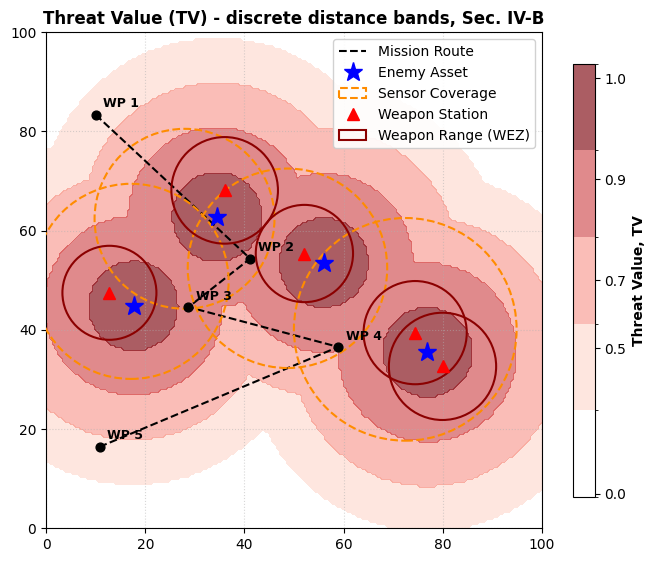

In [3]:
from matplotlib.colors import ListedColormap, BoundaryNorm

grid_x, grid_y = np.meshgrid(np.linspace(0, 100, 200), np.linspace(0, 100, 200))

# Threat Value, TV (Sec. IV-B): discrete distance bands instead of a continuous
# gradient. The paper defines 5 discrete levels based on proximity to the asset:
#   TV = 1.0   very close
#   TV = 0.9   close
#   TV = 0.7   medium
#   TV = 0.5   far
#   TV = 0.0   very far
influence_radius = 45.0

def threat_value_band(distance, R=influence_radius):
    """Discrete threat-value step function, Sec. IV-B."""
    conditions = [distance <= 0.2 * R,
                  distance <= 0.4 * R,
                  distance <= 0.6 * R,
                  distance <= 0.8 * R]
    choices = [1.0, 0.9, 0.7, 0.5]
    return np.select(conditions, choices, default=0.0)

threat_grid = np.zeros_like(grid_x)
for asset in assets:
    ax_pos, ay_pos = asset["pos"]
    distance = np.sqrt((grid_x - ax_pos)**2 + (grid_y - ay_pos)**2)
    asset_threat = threat_value_band(distance)
    threat_grid = np.maximum(threat_grid, asset_threat)

fig, ax3 = plt.subplots(figsize=(8, 7.5))

# Discrete colormap with hard edges at each TV band (no interpolation/gradient)
tv_levels  = [0.0, 0.5, 0.7, 0.9, 1.0]
tv_bounds  = [-0.01, 0.25, 0.6, 0.8, 0.95, 1.01]
tv_colors  = plt.cm.Reds(np.linspace(0.25, 0.95, len(tv_levels)))
tv_colors[:, 3] = [0.0, 0.2, 0.35, 0.5, 0.65]   # opacity per band (0 -> transparent)
custom_cmap = ListedColormap(tv_colors)
norm = BoundaryNorm(tv_bounds, custom_cmap.N)

contour_plot = ax3.contourf(grid_x, grid_y, threat_grid, levels=tv_bounds, cmap=custom_cmap, norm=norm)

ax3.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax3.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax3.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for asset in assets:
    ax3.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7, label='Enemy Asset' if asset == assets[0] else "")

for i, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, zorder=4, label='Sensor Coverage' if i == 0 else "")
    ax3.add_patch(circle)

for i, weapon in enumerate(weapons):
    xw, yw = weapon["station"]

    ax3.plot(xw, yw, 'r^', ms=9, zorder=5, label='Weapon Station' if i == 0 else "")
    wez_edge = patches.Circle((xw, yw), weapon["radius"],
                               edgecolor='darkred', facecolor='none',
                               lw=1.5, zorder=5,
                               label='Weapon Range (WEZ)' if i == 0 else "")
    ax3.add_patch(wez_edge)

ax3.set_title("Threat Value (TV) - discrete distance bands, Sec. IV-B", fontsize=12, weight='bold')
ax3.set_xlim(0, 100); ax3.set_ylim(0, 100); ax3.grid(True, ls=':', alpha=0.5); ax3.set_aspect('equal')
cbar = fig.colorbar(contour_plot, ax=ax3, shrink=0.75, pad=0.05, ticks=tv_levels)
cbar.set_label('Threat Value, TV', weight='bold')

ax3.legend(loc='upper right', framealpha=0.9)
plt.show()


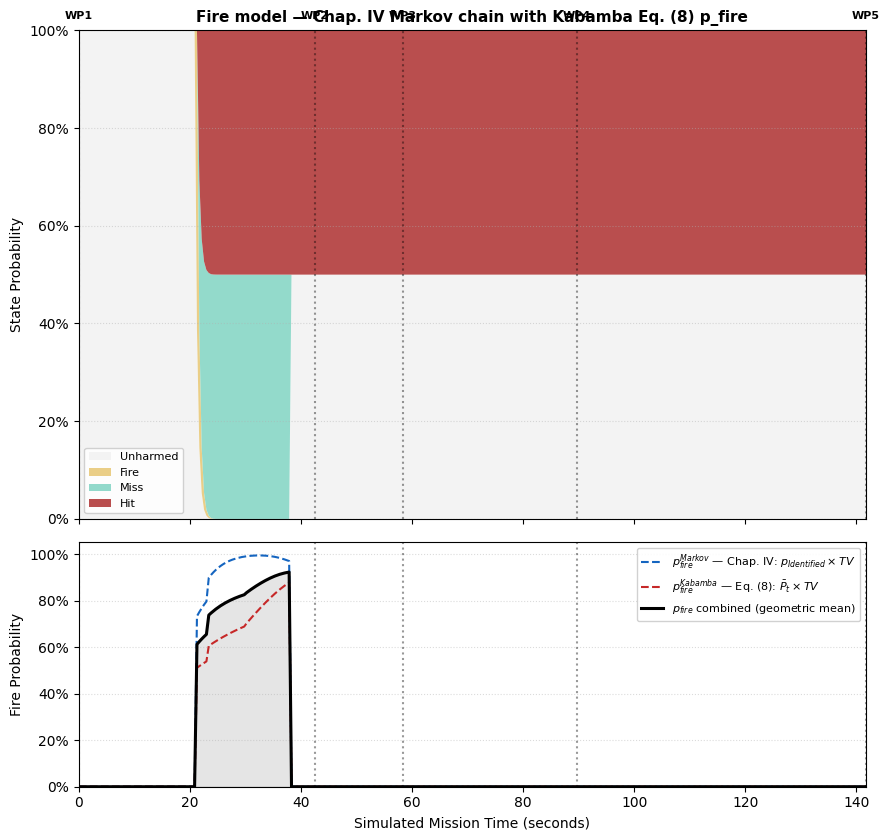

In [4]:
# Fire model (Chap. IV) — discrete-time Markov chain, 4 states:
#   0: Unharmed, 1: Fire, 2: Miss, 3: Hit
#
# p_fire is now computed from TWO complementary sources:
#
#   (A) TUSAS Chap. IV:  p_fire_markov  = p_Identified * TV  (Markov chain source)
#   (B) Kabamba Eq. (8): p_fire_kabamba = pt_moving_avg * TV  (physics bound)
#
# The Kabamba moving average already captured in pt_moving_avg IS the upper
# bound Pd(t) from Eq. (8).  We combine them as a weighted product so that
# a firing event requires BOTH the state-chain to have progressed to "Identified"
# AND the radar to have maintained tracking over the threat window:
#
#   p_fire = sqrt(p_fire_markov * p_fire_kabamba)   (geometric mean)

p_identified    = prob_history[:, 3]
influence_radius = 45.0

path_threat_values = np.zeros(len(path_points))
inside_wez         = np.zeros(len(path_points), dtype=bool)

for t, pos in enumerate(path_points):
    tv = 0.0
    for asset in assets:
        dist = np.linalg.norm(pos - asset["pos"])
        tv   = max(tv, threat_value_band(dist, influence_radius))
    path_threat_values[t] = tv
    for weapon in weapons:
        xw, yw = weapon["station"]
        if np.linalg.norm(pos - np.array([xw, yw])) <= weapon["radius"]:
            inside_wez[t] = True
            break

# (A) Markov-chain-based p_fire (Chap. IV)
p_fire_markov  = np.where(inside_wez, p_identified   * path_threat_values, 0.0)

# (B) Kabamba Eq. (8) physics bound on fire probability
p_fire_kabamba = np.where(inside_wez, pt_moving_avg  * path_threat_values, 0.0)

p_fire = np.sqrt(p_fire_markov * p_fire_kabamba)

p_kill = 0.5

fire_probs = np.zeros((len(path_points), 4))
fire_probs[0] = [1.0, 0.0, 0.0, 0.0]

for t in range(1, len(path_points)):
    pf = p_fire[t]
    P  = np.array([
        [1.0 - pf, pf,        0.0,             0.0   ],
        [0.0,      0.0,       1.0 - p_kill,    p_kill ],
        [0.0,      0.0,       1.0,             0.0   ],
        [0.0,      0.0,       0.0,             1.0   ],
    ])
    fire_probs[t] = fire_probs[t - 1] @ P

    # Damage-assessment rule: clear transient Fire/Miss mass when leaving WEZ
    if inside_wez[t - 1] and not inside_wez[t]:
        fire_probs[t, 0] += fire_probs[t, 1] + fire_probs[t, 2]
        fire_probs[t, 1]  = 0.0
        fire_probs[t, 2]  = 0.0

# ── Plot: fire-model states + both p_fire components ─────────────────────────
fig, (ax_fire, ax_pf) = plt.subplots(2, 1, figsize=(9, 8.5), sharex=True,
                                      gridspec_kw={"height_ratios": [2, 1]})

# Upper panel: stacked fire states
ax_fire.stackplot(time_steps,
                  fire_probs[:, 0], fire_probs[:, 1],
                  fire_probs[:, 2], fire_probs[:, 3],
                  labels=['Unharmed', 'Fire', 'Miss', 'Hit'],
                  colors=['#f2f2f2', '#e8c97a', '#87d6c6', '#b23b3b'], alpha=0.9)
ax_fire.set_title("Fire model — Chap. IV Markov chain with Kabamba Eq. (8) p_fire",
                  fontsize=11, weight='bold')
ax_fire.set_ylabel("State Probability")
ax_fire.set_ylim(0, 1.0)
ax_fire.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_fire.legend(loc='lower left', framealpha=0.9, fontsize=8)
ax_fire.grid(axis='y', ls=':', alpha=0.45)

for idx, i in enumerate(wp_indices):
    tv = time_steps[min(i, len(time_steps) - 1)]
    ax_fire.axvline(tv, color='black', ls=':', alpha=0.4)
    ax_fire.text(tv, 1.02, f"WP{idx+1}", ha='center', va='bottom',
                 fontsize=8, weight='bold')

ax_pf.plot(time_steps, p_fire_markov,  '--', color='#1565c0', lw=1.5,
           label='$p_{fire}^{Markov}$ — Chap. IV: $p_{Identified} \\times TV$')
ax_pf.plot(time_steps, p_fire_kabamba, '--', color='#c62828', lw=1.5,
           label='$p_{fire}^{Kabamba}$ — Eq. (8): $\\bar{P}_t \\times TV$')
ax_pf.plot(time_steps, p_fire,         '-',  color='black',   lw=2.2,
           label='$p_{fire}$ combined (geometric mean)')
ax_pf.fill_between(time_steps, p_fire, alpha=0.10, color='black')

ax_pf.set_xlabel("Simulated Mission Time (seconds)")
ax_pf.set_ylabel("Fire Probability")
ax_pf.set_ylim(0, 1.05)
ax_pf.set_xlim(0, time_steps[-1])
ax_pf.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_pf.legend(loc='upper right', framealpha=0.9, fontsize=8)
ax_pf.grid(axis='y', ls=':', alpha=0.45)

for idx, i in enumerate(wp_indices):
    tv = time_steps[min(i, len(time_steps) - 1)]
    ax_pf.axvline(tv, color='black', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()


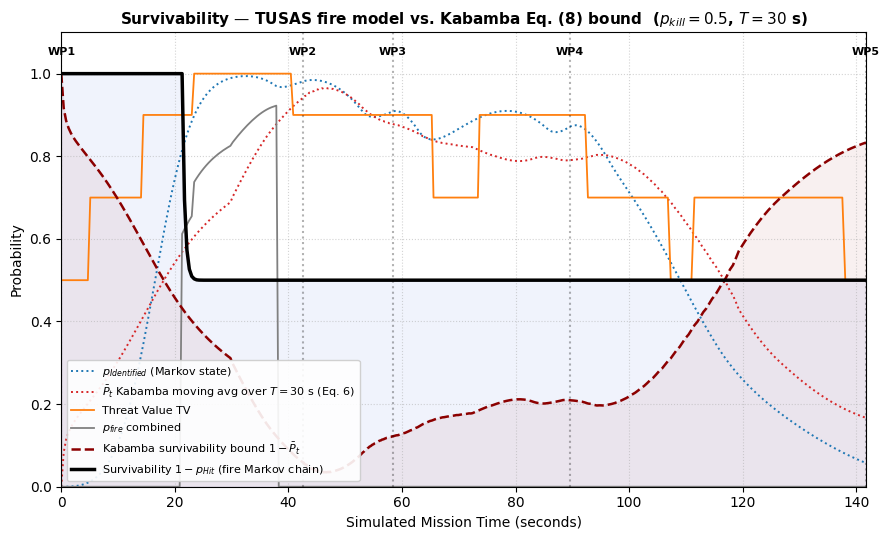


Final results:
  Survivability (fire Markov, 1-p_Hit): 50.0%
  Kabamba Pd upper bound (max):         96.5%
  Kabamba survivability lower bound:     3.5%
  Peak p_fire (combined):               0.923


In [5]:
# Survivability (Sec. V): 1 − p_Hit from the fire Markov chain.
# Also show the Kabamba Eq. (8) upper bound on shoot-down probability
# (max of the moving average across the entire route) for comparison.

survival_prob    = 1.0 - fire_probs[:, 3]
kabamba_pd_bound = pt_moving_avg                 # upper bound on Pd from Eq. (8)
kabamba_survival = 1.0 - kabamba_pd_bound        # Kabamba survivability lower bound

fig, ax5 = plt.subplots(figsize=(9, 5.5))

ax5.fill_between(time_steps, survival_prob,    alpha=0.08, color='royalblue')
ax5.fill_between(time_steps, kabamba_survival, alpha=0.06, color='darkred')

ax5.plot(time_steps, p_identified,    ':',  color='tab:blue',  lw=1.4,
         label='$p_{Identified}$ (Markov state)')
ax5.plot(time_steps, pt_moving_avg,   ':',  color='tab:red',   lw=1.4,
         label=f'$\\bar{{P}}_t$ Kabamba moving avg over $T={T_threat:.0f}$ s (Eq. 6)')
ax5.plot(time_steps, path_threat_values, '-', color='tab:orange', lw=1.3,
         label='Threat Value TV')
ax5.plot(time_steps, p_fire,          '-',  color='gray',      lw=1.3,
         label='$p_{fire}$ combined')
ax5.plot(time_steps, kabamba_survival, '--', color='darkred',  lw=1.8,
         label='Kabamba survivability bound $1 - \\bar{P}_t$')
ax5.plot(time_steps, survival_prob,   'k-',                    lw=2.5,
         label='Survivability $1 - p_{Hit}$ (fire Markov chain)')

for idx, i in enumerate(wp_indices):
    tv = time_steps[min(i, len(time_steps) - 1)]
    ax5.axvline(tv, color='black', ls=':', alpha=0.3)
    ax5.text(tv, 1.04, f"WP{idx+1}", ha='center', va='bottom',
             fontsize=8, weight='bold')

ax5.set_title(f"Survivability — TUSAS fire model vs. Kabamba Eq. (8) bound  "
              f"($p_{{kill}}={p_kill}$, $T={T_threat:.0f}$ s)", fontsize=11, weight='bold')
ax5.set_xlabel("Simulated Mission Time (seconds)")
ax5.set_ylabel("Probability")
ax5.set_ylim(0.0, 1.10)
ax5.set_xlim(0, time_steps[-1])
ax5.grid(True, ls=':', alpha=0.55)
ax5.legend(loc='lower left', framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nFinal results:")
print(f"  Survivability (fire Markov, 1-p_Hit): {survival_prob[-1]:.1%}")
print(f"  Kabamba Pd upper bound (max):         {pt_moving_avg.max():.1%}")
print(f"  Kabamba survivability lower bound:     {1.0 - pt_moving_avg.max():.1%}")
print(f"  Peak p_fire (combined):               {p_fire.max():.3f}")
